# Notebook 18A — TRAIN-only implied-volatility event-alignment audit

This diagnostic compares the existing session-contained realised event model day with an externally motivated 10:00 New York FX-option cut candidate. It does not identify Bloomberg's proprietary historical snapshot or date-labelling convention, fit an eventless model, calculate event weights, rewrite Notebook 18, or use VALIDATION/TEST observations to choose an alignment rule.

Canonical chronology is preserved: model day D is the half-open interval [D-1 17:00 New York, D 17:00 New York).

In [2]:
from pathlib import Path
from zoneinfo import ZoneInfo
from hashlib import sha256
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 100)

NY = ZoneInfo("America/New_York")
IV_COLUMN = "iv_model_var"
FAMILY_ORDER = ["FOMC", "US Employment", "US CPI", "BoJ", "JPY National CPI", "JPY GDP"]
RELATIVE_OFFSETS = [-2, -1, 0, 1]
BOOTSTRAP_REPETITIONS = 5_000
BOOTSTRAP_SEED = 18018

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "Data" / "processed").exists()
)
PROCESSED = PROJECT_ROOT / "Data" / "processed"
INPUT_FILES = {
    "notebook16_panel": PROCESSED / "16_empirical_analysis_panel.csv",
    "notebook17_specification": PROCESSED / "17_primary_specification.csv",
    "notebook18_mapping_audit": PROCESSED / "18_event_mapping_audit.csv",
    "notebook18_occurrences": PROCESSED / "18_event_occurrences.csv",
}
assert all(path.exists() for path in INPUT_FILES.values()), {
    name: str(path) for name, path in INPUT_FILES.items() if not path.exists()
}

def file_sha256(path):
    digest = sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1 << 20), b""):
            digest.update(block)
    return digest.hexdigest()

input_hashes_before = {name: file_sha256(path) for name, path in INPUT_FILES.items()}
print(f"Project root: {PROJECT_ROOT}")
print(f"Bootstrap: {BOOTSTRAP_REPETITIONS:,} occurrence resamples; seed={BOOTSTRAP_SEED}")

Project root: c:\Users\Rajiv Nawal\OneDrive\Documents\GITREPOS\HSBC-AN-RN\CODEWORK\Linus' Task Re-Do
Bootstrap: 5,000 occurrence resamples; seed=18018


## Frozen inputs and source-contract checks

Notebook 17 reads the canonical Notebook 16 panel and freezes its chronological split. Notebook 18 reads that same panel, retains the audited UTC event timestamps, maps raw rows by explicit New York session containment, and collapses them to family × realised model-day occurrences. The checks below reproduce those contracts from the current exports; they do not reconstruct or replace upstream variables.

In [3]:
panel = (
    pd.read_csv(INPUT_FILES["notebook16_panel"], parse_dates=["date", "model_day"])
    .sort_values("model_day")
    .reset_index(drop=True)
)
spec17 = pd.read_csv(INPUT_FILES["notebook17_specification"])
mapping_audit = pd.read_csv(INPUT_FILES["notebook18_mapping_audit"])
occurrences_raw = pd.read_csv(INPUT_FILES["notebook18_occurrences"], dtype=str)
occurrences = pd.read_csv(INPUT_FILES["notebook18_occurrences"], parse_dates=["model_day"])

mapping_audit["mapped_model_day"] = pd.to_datetime(mapping_audit["mapped_model_day"], errors="coerce")
mapping_audit["event_datetime_utc"] = pd.to_datetime(
    mapping_audit["event_datetime_utc"], utc=True, errors="coerce", format="mixed"
)
occurrences["first_event_time_utc"] = pd.to_datetime(
    occurrences["first_event_time_utc"], utc=True, errors="raise", format="mixed"
)
occurrences["last_event_time_utc"] = pd.to_datetime(
    occurrences["last_event_time_utc"], utc=True, errors="raise", format="mixed"
)
occurrences["event_timestamp_original"] = occurrences_raw["first_event_time_utc"].to_numpy()

required_panel = {"model_day", "sample_split", IV_COLUMN}
required_occurrences = {
    "family", "model_day", "raw_row_count", "raw_labels", "n_unique_raw_timestamps",
    "first_event_time_utc", "last_event_time_utc", "sample_split",
    "is_clean_single_family", "is_overlap",
}
assert required_panel.issubset(panel.columns)
assert required_occurrences.issubset(occurrences.columns)
assert panel["model_day"].is_unique and panel["model_day"].is_monotonic_increasing
assert set(panel["sample_split"]) == {"train", "validation", "test"}
assert set(occurrences["family"]) == set(FAMILY_ORDER)
assert not occurrences.duplicated(["family", "model_day"]).any()
assert spec17.loc[0, "iv_column"] == IV_COLUMN
assert int(spec17.loc[0, "selected_n"]) == 1
assert int(spec17.loc[0, "selected_m"]) == 12

split_summary = (
    panel.groupby("sample_split", sort=False)["model_day"]
    .agg(start="min", end="max", n_model_days="size")
    .reindex(["train", "validation", "test"])
)
frozen_train_start = pd.Timestamp("2003-05-05")
frozen_train_end = pd.Timestamp("2017-03-27")
assert split_summary.loc["train", "start"] == frozen_train_start
assert split_summary.loc["train", "end"] == frozen_train_end
assert split_summary.loc["train", "end"] < split_summary.loc["validation", "start"]
assert split_summary.loc["validation", "end"] < split_summary.loc["test", "start"]

# Reproduce Notebook 18's raw-component collapse from its current mapping audit.
mapped_raw = mapping_audit.loc[mapping_audit["mapping_status"].eq("MAPPED")].copy()
assert mapped_raw["explicit_member"].astype(str).str.lower().eq("true").all()
collapsed_check = (
    mapped_raw.groupby(["mapped_family", "mapped_model_day"], as_index=False)
    .agg(
        checked_raw_row_count=("raw_event_id", "size"),
        checked_first_event_time_utc=("event_datetime_utc", "min"),
        checked_last_event_time_utc=("event_datetime_utc", "max"),
    )
    .rename(columns={"mapped_family": "family", "mapped_model_day": "model_day"})
)
collapse_verification = occurrences.merge(
    collapsed_check, on=["family", "model_day"], how="left", validate="one_to_one"
)
assert collapse_verification["checked_raw_row_count"].notna().all()
assert collapse_verification["raw_row_count"].astype(int).eq(
    collapse_verification["checked_raw_row_count"].astype(int)
).all()
assert collapse_verification["first_event_time_utc"].eq(
    collapse_verification["checked_first_event_time_utc"]
).all()
assert collapse_verification["last_event_time_utc"].eq(
    collapse_verification["checked_last_event_time_utc"]
).all()
assert occurrences["release_span_seconds"].astype(float).max() <= 6.0

display(split_summary)
display(pd.DataFrame({
    "input_role": list(INPUT_FILES),
    "exact_file": [str(path.resolve()) for path in INPUT_FILES.values()],
}))

,start,end,n_model_days
sample_split,,,
train,2003-05-05,2017-03-27,3626
validation,2017-03-28,2021-11-12,1209
test,2021-11-15,2026-07-02,1209


,input_role,exact_file
0,notebook16_panel,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...
1,notebook17_specification,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...
2,notebook18_mapping_audit,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...
3,notebook18_occurrences,C:\Users\Rajiv Nawal\OneDrive\Documents\GITREP...


## Existing mapping and external NY-cut candidate

The realised model day remains the Notebook 18 session-containment result. The candidate compares 10:00 America/New_York on calendar date D with the earliest exact timestamp in each coherent component bundle. The current bundles span no more than six seconds, and an assertion below requires that no bundle straddle the cut. “Previous” means the previous row of the canonical panel, never D minus one calendar day.

In [4]:
model_days = panel["model_day"].copy()
previous_available = pd.Series(model_days.shift(1).to_numpy(), index=model_days)

alignment = occurrences.copy()
alignment["event_id"] = (
    alignment["family"].str.replace(r"[^A-Za-z0-9]+", "_", regex=True).str.strip("_")
    + "__" + alignment["model_day"].dt.strftime("%Y%m%d")
)
alignment["event_label"] = alignment["family"]
alignment["event_timestamp_ny"] = alignment["first_event_time_utc"].dt.tz_convert(NY)
alignment["last_event_timestamp_ny"] = alignment["last_event_time_utc"].dt.tz_convert(NY)
alignment["realised_model_day"] = alignment["model_day"]

cut_naive = (
    pd.to_datetime(alignment["realised_model_day"].dt.date)
    + pd.Timedelta(hours=10)
)
alignment["cut_timestamp_ny"] = cut_naive.dt.tz_localize(NY)
component_bundle_straddles_cut = (
    alignment["event_timestamp_ny"].lt(alignment["cut_timestamp_ny"])
    & alignment["last_event_timestamp_ny"].ge(alignment["cut_timestamp_ny"])
)
assert not component_bundle_straddles_cut.any()

alignment["implied_day_current"] = alignment["realised_model_day"]
alignment["nycut_shift_model_days"] = np.where(
    alignment["event_timestamp_ny"].lt(alignment["cut_timestamp_ny"]), -1, 0
).astype(int)
alignment["implied_day_nycut"] = alignment["realised_model_day"]
shift_mask = alignment["nycut_shift_model_days"].eq(-1)
alignment.loc[shift_mask, "implied_day_nycut"] = (
    alignment.loc[shift_mask, "realised_model_day"].map(previous_available)
)
assert alignment.loc[shift_mask, "implied_day_nycut"].notna().all()
assert alignment["realised_model_day"].eq(occurrences["model_day"]).all()
assert alignment["implied_day_current"].eq(alignment["realised_model_day"]).all()
assert alignment.loc[shift_mask, "implied_day_nycut"].eq(
    alignment.loc[shift_mask, "realised_model_day"].map(previous_available)
).all()
assert alignment.loc[~shift_mask, "implied_day_nycut"].eq(
    alignment.loc[~shift_mask, "realised_model_day"]
).all()

alignment_audit_table = alignment[[
    "event_id", "event_label", "family", "raw_labels", "event_timestamp_original",
    "event_timestamp_ny", "realised_model_day", "cut_timestamp_ny",
    "implied_day_current", "implied_day_nycut", "nycut_shift_model_days",
    "sample_split", "is_clean_single_family", "is_overlap",
    "raw_row_count", "n_unique_raw_timestamps",
]].sort_values(["realised_model_day", "family"]).reset_index(drop=True)

train_alignment = alignment.loc[alignment["sample_split"].eq("train")].copy()
assert len(train_alignment) > 0
assert train_alignment["sample_split"].eq("train").all()
assert not train_alignment["sample_split"].isin(["validation", "test"]).any()

sample_count_table = (
    train_alignment.groupby("family", as_index=False)
    .agg(
        n_train_occurrences=("event_id", "size"),
        n_clean_single_family=("is_clean_single_family", "sum"),
        n_overlap_occurrences=("is_overlap", "sum"),
        n_current_same_day=("implied_day_current", "size"),
        n_nycut_previous_available=("nycut_shift_model_days", lambda x: int(x.eq(-1).sum())),
        n_nycut_same_day=("nycut_shift_model_days", lambda x: int(x.eq(0).sum())),
    )
)
sample_count_table["family"] = pd.Categorical(
    sample_count_table["family"], FAMILY_ORDER, ordered=True
)
sample_count_table = sample_count_table.sort_values("family").reset_index(drop=True)
assert sample_count_table["n_train_occurrences"].sum() == len(train_alignment)

print("Table 1 — event timestamp/alignment audit (full dataframe retained; display is compact)")
display(alignment_audit_table)
print("Initial TRAIN mapping counts")
display(sample_count_table)

Table 1 — event timestamp/alignment audit (full dataframe retained; display is compact)


,event_id,event_label,family,raw_labels,event_timestamp_original,event_timestamp_ny,realised_model_day,cut_timestamp_ny,implied_day_current,implied_day_nycut,nycut_shift_model_days,sample_split,is_clean_single_family,is_overlap,raw_row_count,n_unique_raw_timestamps
0,FOMC__20030506,FOMC,FOMC,FOMC Rate Decision (Upper Bound),2003-05-06 19:13:00+00:00,2003-05-06 15:13:00-04:00,2003-05-06,2003-05-06 10:00:00-04:00,2003-05-06,2003-05-06,0,train,True,False,1,1
1,US_CPI__20030516,US CPI,US CPI,CPI MoM | CPI YoY,2003-05-16 13:30:00+00:00,2003-05-16 09:30:00-04:00,2003-05-16,2003-05-16 10:00:00-04:00,2003-05-16,2003-05-15,-1,train,True,False,2,2
2,JPY_National_CPI__20030530,JPY National CPI,JPY National CPI,Natl CPI YoY,2003-05-30 00:30:08+00:00,2003-05-29 20:30:08-04:00,2003-05-30,2003-05-30 10:00:00-04:00,2003-05-30,2003-05-29,-1,train,True,False,1,1
3,US_Employment__20030606,US Employment,US Employment,Change in Nonfarm Payrolls | Unemployment Rate,2003-06-06 13:30:00+00:00,2003-06-06 09:30:00-04:00,2003-06-06,2003-06-06 10:00:00-04:00,2003-06-06,2003-06-05,-1,train,True,False,2,2
4,US_CPI__20030617,US CPI,US CPI,CPI MoM | CPI YoY,2003-06-17 13:30:00+00:00,2003-06-17 09:30:00-04:00,2003-06-17,2003-06-17 10:00:00-04:00,2003-06-17,2003-06-16,-1,train,True,False,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1409,JPY_GDP__20260608,JPY GDP,JPY GDP,GDP Annualized SA QoQ | GDP Deflator YoY | GDP...,2026-06-08 00:50:00+00:00,2026-06-07 20:50:00-04:00,2026-06-08,2026-06-08 10:00:00-04:00,2026-06-08,2026-06-05,-1,test,True,False,3,1
1410,US_CPI__20260610,US CPI,US CPI,CPI MoM | CPI YoY,2026-06-10 13:30:00+00:00,2026-06-10 09:30:00-04:00,2026-06-10,2026-06-10 10:00:00-04:00,2026-06-10,2026-06-09,-1,test,True,False,2,1
1411,BoJ__20260616,BoJ,BoJ,BOJ Target Rate,2026-06-16 04:19:00+00:00,2026-06-16 00:19:00-04:00,2026-06-16,2026-06-16 10:00:00-04:00,2026-06-16,2026-06-15,-1,test,True,False,1,1
1412,FOMC__20260617,FOMC,FOMC,FOMC Rate Decision (Upper Bound),2026-06-17 19:00:00+00:00,2026-06-17 15:00:00-04:00,2026-06-17,2026-06-17 10:00:00-04:00,2026-06-17,2026-06-17,0,test,True,False,1,1


Initial TRAIN mapping counts


,family,n_train_occurrences,n_clean_single_family,n_overlap_occurrences,n_current_same_day,n_nycut_previous_available,n_nycut_same_day
0,FOMC,114,97,17,114,2,112
1,US Employment,166,158,8,166,166,0
2,US CPI,167,145,22,167,167,0
3,BoJ,146,107,39,146,146,0
4,JPY National CPI,165,153,12,165,165,0
5,JPY GDP,99,90,9,99,99,0


## TRAIN event-time profiles

The primary sample uses clean single-family TRAIN occurrences. The labelled robustness sample includes overlaps. Relative days are panel-row offsets around realised D. Offset observations must themselves remain in TRAIN.

Ordinary reference days are TRAIN model days with defined iv_model_var that are not canonical TRAIN event days. Each occurrence is matched to the ordinary-TRAIN mean and median for the relative day's weekday. The occurrence-level event/baseline ratio uses the weekday-matched ordinary mean; its mean and median are reported. This is a robustness comparison layered on the already weekday-normalised canonical state, not a new normalisation.

In [5]:
event_days_train = set(train_alignment["realised_model_day"])
ordinary_train = panel.loc[
    panel["sample_split"].eq("train")
    & panel[IV_COLUMN].notna()
    & ~panel["model_day"].isin(event_days_train),
    ["model_day", IV_COLUMN],
].copy()
ordinary_train["weekday"] = ordinary_train["model_day"].dt.day_name()
weekday_baseline = (
    ordinary_train.groupby("weekday", as_index=False)
    .agg(
        ordinary_train_n=(IV_COLUMN, "size"),
        weekday_baseline_mean=(IV_COLUMN, "mean"),
        weekday_baseline_median=(IV_COLUMN, "median"),
    )
)
assert ordinary_train["model_day"].isin(panel.loc[panel["sample_split"].eq("train"), "model_day"]).all()
assert not ordinary_train["model_day"].isin(event_days_train).any()
assert len(weekday_baseline) == 5

panel_positions = pd.Series(panel.index.to_numpy(), index=panel["model_day"])
panel_lookup = panel[["model_day", "sample_split", IV_COLUMN]].copy()

def make_profile_observations(event_frame, sample_definition):
    base = event_frame.copy()
    base["event_position"] = base["realised_model_day"].map(panel_positions)
    assert base["event_position"].notna().all()
    expanded = base.loc[base.index.repeat(len(RELATIVE_OFFSETS))].copy()
    expanded["relative_model_day"] = np.tile(RELATIVE_OFFSETS, len(base))
    expanded["profile_position"] = (
        expanded["event_position"].astype(int) + expanded["relative_model_day"]
    )
    expanded = expanded.loc[
        expanded["profile_position"].between(0, len(panel) - 1)
    ].copy()
    expanded["profile_model_day"] = panel["model_day"].to_numpy()[
        expanded["profile_position"].astype(int).to_numpy()
    ]
    expanded = expanded.merge(
        panel_lookup.rename(columns={
            "model_day": "profile_model_day",
            "sample_split": "profile_sample_split",
        }),
        on="profile_model_day",
        how="left",
        validate="many_to_one",
    )
    expanded = expanded.loc[
        expanded["profile_sample_split"].eq("train") & expanded[IV_COLUMN].notna()
    ].copy()
    expanded["weekday"] = expanded["profile_model_day"].dt.day_name()
    expanded = expanded.merge(
        weekday_baseline, on="weekday", how="left", validate="many_to_one"
    )
    expanded["event_to_baseline_ratio"] = (
        expanded[IV_COLUMN] / expanded["weekday_baseline_mean"]
    )
    expanded["sample_definition"] = sample_definition
    assert expanded["sample_split"].eq("train").all()
    assert expanded["profile_sample_split"].eq("train").all()
    assert not expanded[["sample_split", "profile_sample_split"]].isin(
        ["validation", "test"]
    ).any().any()
    return expanded

clean_profile_observations = make_profile_observations(
    train_alignment.loc[train_alignment["is_clean_single_family"]].copy(),
    "PRIMARY_CLEAN_TRAIN",
)
overlap_profile_observations = make_profile_observations(
    train_alignment.copy(),
    "OVERLAP_INCLUSIVE_TRAIN_ROBUSTNESS",
)
profile_observations = pd.concat(
    [clean_profile_observations, overlap_profile_observations],
    ignore_index=True,
)

def percentile_mean_ci(values, rng):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < 2:
        return np.nan, np.nan
    draws = rng.choice(
        values, size=(BOOTSTRAP_REPETITIONS, len(values)), replace=True
    ).mean(axis=1)
    return tuple(np.quantile(draws, [0.025, 0.975]))

profile_rng = np.random.default_rng(BOOTSTRAP_SEED)
profile_rows = []
group_columns = ["sample_definition", "family", "relative_model_day"]
for keys, group in profile_observations.groupby(group_columns, sort=True):
    lower, upper = percentile_mean_ci(
        group["event_to_baseline_ratio"].to_numpy(float), profile_rng
    )
    profile_rows.append({
        "sample_definition": keys[0],
        "family": keys[1],
        "relative_model_day": int(keys[2]),
        "n_valid_occurrences": int(group["event_id"].nunique()),
        "mean_iv_model_var": float(group[IV_COLUMN].mean()),
        "median_iv_model_var": float(group[IV_COLUMN].median()),
        "mean_weekday_matched_ordinary_train_baseline": float(
            group["weekday_baseline_mean"].mean()
        ),
        "median_weekday_matched_ordinary_train_baseline": float(
            group["weekday_baseline_median"].median()
        ),
        "mean_event_to_baseline_ratio": float(
            group["event_to_baseline_ratio"].mean()
        ),
        "median_event_to_baseline_ratio": float(
            group["event_to_baseline_ratio"].median()
        ),
        "mean_ratio_bootstrap_ci_lower": float(lower),
        "mean_ratio_bootstrap_ci_upper": float(upper),
        "bootstrap_repetitions": BOOTSTRAP_REPETITIONS,
        "bootstrap_seed": BOOTSTRAP_SEED,
        "bootstrap_unit": "canonical event occurrence",
    })
family_event_time_profile = pd.DataFrame(profile_rows)
family_event_time_profile["family"] = pd.Categorical(
    family_event_time_profile["family"], FAMILY_ORDER, ordered=True
)
family_event_time_profile = family_event_time_profile.sort_values(
    ["sample_definition", "family", "relative_model_day"]
).reset_index(drop=True)
assert set(family_event_time_profile["relative_model_day"]) == set(RELATIVE_OFFSETS)
assert family_event_time_profile["bootstrap_repetitions"].eq(5000).all()

print("Table 2 — family event-time profile")
display(family_event_time_profile)

Table 2 — family event-time profile


,sample_definition,family,relative_model_day,n_valid_occurrences,mean_iv_model_var,median_iv_model_var,mean_weekday_matched_ordinary_train_baseline,median_weekday_matched_ordinary_train_baseline,mean_event_to_baseline_ratio,median_event_to_baseline_ratio,mean_ratio_bootstrap_ci_lower,mean_ratio_bootstrap_ci_upper,bootstrap_repetitions,bootstrap_seed,bootstrap_unit
0,OVERLAP_INCLUSIVE_TRAIN_ROBUSTNESS,FOMC,-2,97,0.024617,0.012547,0.016999,0.011889,1.451655,0.727215,0.872820,2.403001,5000,18018,canonical event occurrence
1,OVERLAP_INCLUSIVE_TRAIN_ROBUSTNESS,FOMC,-1,106,0.019564,0.011614,0.016138,0.011754,1.212050,0.711722,0.898758,1.642132,5000,18018,canonical event occurrence
2,OVERLAP_INCLUSIVE_TRAIN_ROBUSTNESS,FOMC,0,103,0.024253,0.014251,0.015566,0.011683,1.563265,0.928217,1.181421,2.037991,5000,18018,canonical event occurrence
3,OVERLAP_INCLUSIVE_TRAIN_ROBUSTNESS,FOMC,1,107,0.021359,0.012545,0.016423,0.011889,1.302006,0.765009,1.019978,1.654626,5000,18018,canonical event occurrence
4,OVERLAP_INCLUSIVE_TRAIN_ROBUSTNESS,US Employment,-2,157,0.015124,0.011869,0.015342,0.011683,0.986816,0.775798,0.858387,1.142375,5000,18018,canonical event occurrence
5,OVERLAP_INCLUSIVE_TRAIN_ROBUSTNESS,US Employment,-1,151,0.022662,0.018175,0.016758,0.011889,1.351751,1.083623,1.208015,1.517315,5000,18018,canonical event occurrence
6,OVERLAP_INCLUSIVE_TRAIN_ROBUSTNESS,US Employment,0,144,0.016597,0.012581,0.018476,0.011216,0.896667,0.678059,0.778796,1.022693,5000,18018,canonical event occurrence
7,OVERLAP_INCLUSIVE_TRAIN_ROBUSTNESS,US Employment,1,153,0.015838,0.011508,0.016678,0.011889,0.950536,0.691705,0.791301,1.158450,5000,18018,canonical event occurrence
8,OVERLAP_INCLUSIVE_TRAIN_ROBUSTNESS,US CPI,-2,151,0.016301,0.011889,0.016441,0.011754,0.995424,0.726507,0.847510,1.162099,5000,18018,canonical event occurrence
9,OVERLAP_INCLUSIVE_TRAIN_ROBUSTNESS,US CPI,-1,159,0.016378,0.012560,0.016179,0.011754,1.016911,0.760834,0.885385,1.168907,5000,18018,canonical event occurrence


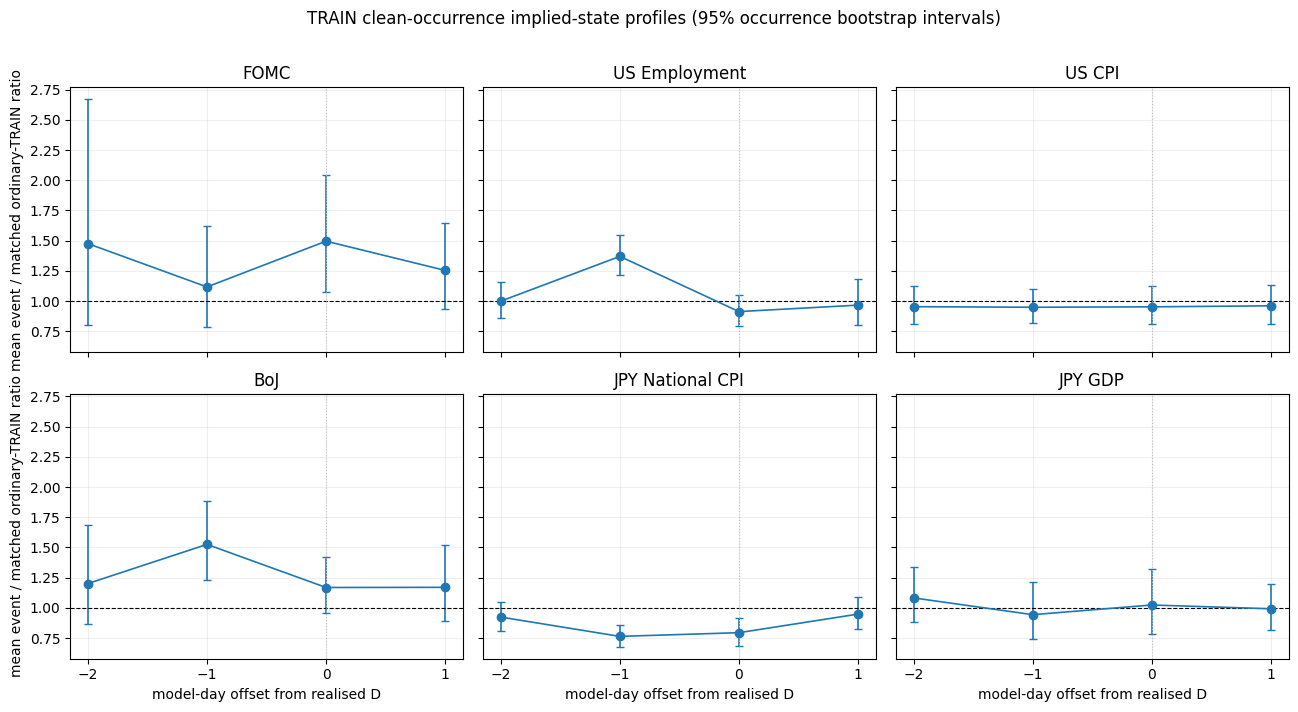

In [6]:
primary_profile = family_event_time_profile.loc[
    family_event_time_profile["sample_definition"].eq("PRIMARY_CLEAN_TRAIN")
].copy()

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
for axis, family in zip(axes.flat, FAMILY_ORDER):
    data = (
        primary_profile.loc[primary_profile["family"].eq(family)]
        .sort_values("relative_model_day")
    )
    x = data["relative_model_day"].to_numpy(float)
    y = data["mean_event_to_baseline_ratio"].to_numpy(float)
    lower = data["mean_ratio_bootstrap_ci_lower"].to_numpy(float)
    upper = data["mean_ratio_bootstrap_ci_upper"].to_numpy(float)
    errors = np.vstack([
        np.maximum(0.0, y - lower),
        np.maximum(0.0, upper - y),
    ])
    axis.errorbar(x, y, yerr=errors, marker="o", capsize=3, linewidth=1.2)
    axis.axhline(1.0, color="black", linestyle="--", linewidth=0.8)
    axis.axvline(0.0, color="0.75", linestyle=":", linewidth=0.8)
    axis.set_title(family)
    axis.set_xticks(RELATIVE_OFFSETS)
    axis.grid(alpha=0.2)
for axis in axes[:, 0]:
    axis.set_ylabel("mean event / matched ordinary-TRAIN ratio")
for axis in axes[-1, :]:
    axis.set_xlabel("model-day offset from realised D")
fig.suptitle(
    "TRAIN clean-occurrence implied-state profiles (95% occurrence bootstrap intervals)",
    y=1.01,
)
fig.tight_layout()
plt.show()

## Direct paired alignment contrasts

For a clean TRAIN occurrence in a non-FOMC family shifted by the candidate, the diagnostic contrast is I(D-1) − I(D). For all eligible clean FOMC occurrences, the requested comparator is I(D) − I(D-1), reflecting the usual 14:00 ET announcement. Two pre-10:00 emergency FOMC decisions remain explicit in the occurrence-level mapping table and counts, but FOMC is not folded into the pooled shifted-family estimator. Both paired days must be available, defined, and in TRAIN.

In [7]:
iv_lookup = panel.set_index("model_day")[IV_COLUMN]
split_lookup = panel.set_index("model_day")["sample_split"]

pair_base = train_alignment.loc[
    train_alignment["is_clean_single_family"]
].copy()
pair_base["previous_available_model_day"] = pair_base[
    "realised_model_day"
].map(previous_available)
pair_base["iv_D"] = pair_base["realised_model_day"].map(iv_lookup)
pair_base["iv_D_minus_1"] = pair_base["previous_available_model_day"].map(iv_lookup)
pair_base["D_split"] = pair_base["realised_model_day"].map(split_lookup)
pair_base["D_minus_1_split"] = pair_base["previous_available_model_day"].map(split_lookup)
pair_base["pair_train_eligible"] = (
    pair_base["D_split"].eq("train")
    & pair_base["D_minus_1_split"].eq("train")
    & pair_base[["iv_D", "iv_D_minus_1"]].notna().all(axis=1)
)

shifted_pairs = pair_base.loc[
    pair_base["nycut_shift_model_days"].eq(-1)
    & pair_base["family"].ne("FOMC")
    & pair_base["pair_train_eligible"]
].copy()
shifted_pairs["contrast"] = shifted_pairs["iv_D_minus_1"] - shifted_pairs["iv_D"]
shifted_pairs["contrast_definition"] = "I(D-1) - I(D)"
shifted_pairs["candidate_role"] = "NY-cut previous-available candidate"

fomc_pairs = pair_base.loc[
    pair_base["family"].eq("FOMC")
    & pair_base["pair_train_eligible"]
].copy()
fomc_pairs["contrast"] = fomc_pairs["iv_D"] - fomc_pairs["iv_D_minus_1"]
fomc_pairs["contrast_definition"] = "I(D) - I(D-1)"
fomc_pairs["candidate_role"] = "FOMC comparator; usual candidate remains on D"

paired_observations = pd.concat([shifted_pairs, fomc_pairs], ignore_index=True)
assert paired_observations["sample_split"].eq("train").all()
assert paired_observations["D_split"].eq("train").all()
assert paired_observations["D_minus_1_split"].eq("train").all()
assert not paired_observations[
    ["sample_split", "D_split", "D_minus_1_split"]
].isin(["validation", "test"]).any().any()

paired_rng = np.random.default_rng(BOOTSTRAP_SEED + 1)
paired_rows = []
for (family, definition, role), group in paired_observations.groupby(
    ["family", "contrast_definition", "candidate_role"], sort=True
):
    lower, upper = percentile_mean_ci(group["contrast"].to_numpy(float), paired_rng)
    paired_rows.append({
        "family": family,
        "candidate_role": role,
        "contrast_definition": definition,
        "n": int(len(group)),
        "mean_contrast": float(group["contrast"].mean()),
        "median_contrast": float(group["contrast"].median()),
        "mean_bootstrap_ci_lower": float(lower),
        "mean_bootstrap_ci_upper": float(upper),
        "bootstrap_repetitions": BOOTSTRAP_REPETITIONS,
        "bootstrap_seed": BOOTSTRAP_SEED + 1,
        "bootstrap_unit": "canonical event occurrence",
    })
family_paired_contrasts = pd.DataFrame(paired_rows)
family_paired_contrasts["family"] = pd.Categorical(
    family_paired_contrasts["family"], FAMILY_ORDER, ordered=True
)
family_paired_contrasts = family_paired_contrasts.sort_values("family").reset_index(
    drop=True
)

pooled_rng = np.random.default_rng(BOOTSTRAP_SEED + 2)
pooled_lower, pooled_upper = percentile_mean_ci(
    shifted_pairs["contrast"].to_numpy(float), pooled_rng
)
pooled_shifted_family_contrast = pd.DataFrame([{
    "pool": "ALL_NYCUT_SHIFTED_FAMILIES_CLEAN_TRAIN",
    "contrast_definition": "I(D-1) - I(D)",
    "n": int(len(shifted_pairs)),
    "n_families": int(shifted_pairs["family"].nunique()),
    "mean_contrast": float(shifted_pairs["contrast"].mean()),
    "median_contrast": float(shifted_pairs["contrast"].median()),
    "mean_bootstrap_ci_lower": float(pooled_lower),
    "mean_bootstrap_ci_upper": float(pooled_upper),
    "bootstrap_repetitions": BOOTSTRAP_REPETITIONS,
    "bootstrap_seed": BOOTSTRAP_SEED + 2,
    "bootstrap_unit": "canonical event occurrence",
}])

profile_complete = (
    clean_profile_observations.groupby(["family", "event_id"])
    ["relative_model_day"].nunique()
    .eq(len(RELATIVE_OFFSETS))
    .groupby(level=0).sum()
    .rename("n_clean_profile_complete_all_offsets")
)
pair_eligible_counts = (
    paired_observations.groupby("family").size().rename("n_clean_pair_eligible")
)
sample_count_table = (
    sample_count_table.merge(profile_complete, on="family", how="left")
    .merge(pair_eligible_counts, on="family", how="left")
)
for column in [
    "n_clean_profile_complete_all_offsets", "n_clean_pair_eligible"
]:
    sample_count_table[column] = sample_count_table[column].fillna(0).astype(int)

print("Table 3 — family paired D-1 versus D contrasts")
display(family_paired_contrasts)
print("Table 4 — pooled shifted-family contrast")
display(pooled_shifted_family_contrast)
print("Table 5 — TRAIN sample counts and eligibility")
display(sample_count_table)

Table 3 — family paired D-1 versus D contrasts


,family,candidate_role,contrast_definition,n,mean_contrast,median_contrast,mean_bootstrap_ci_lower,mean_bootstrap_ci_upper,bootstrap_repetitions,bootstrap_seed,bootstrap_unit
0,FOMC,FOMC comparator; usual candidate remains on D,I(D) - I(D-1),85,0.005107,0.002279,0.001689,0.008977,5000,18019,canonical event occurrence
1,US Employment,NY-cut previous-available candidate,I(D-1) - I(D),128,0.007542,0.007416,0.005477,0.009563,5000,18019,canonical event occurrence
2,US CPI,NY-cut previous-available candidate,I(D-1) - I(D),127,-0.000463,0.000279,-0.001931,0.000937,5000,18019,canonical event occurrence
3,BoJ,NY-cut previous-available candidate,I(D-1) - I(D),107,0.005465,0.002791,0.002576,0.008355,5000,18019,canonical event occurrence
4,JPY National CPI,NY-cut previous-available candidate,I(D-1) - I(D),123,-0.001576,-0.000904,-0.003045,-0.000317,5000,18019,canonical event occurrence
5,JPY GDP,NY-cut previous-available candidate,I(D-1) - I(D),80,-0.000862,0.000751,-0.003884,0.001539,5000,18019,canonical event occurrence


Table 4 — pooled shifted-family contrast


,pool,contrast_definition,n,n_families,mean_contrast,median_contrast,mean_bootstrap_ci_lower,mean_bootstrap_ci_upper,bootstrap_repetitions,bootstrap_seed,bootstrap_unit
0,ALL_NYCUT_SHIFTED_FAMILIES_CLEAN_TRAIN,I(D-1) - I(D),565,5,0.002174,0.001502,0.001205,0.00314,5000,18020,canonical event occurrence


Table 5 — TRAIN sample counts and eligibility


,family,n_train_occurrences,n_clean_single_family,n_overlap_occurrences,n_current_same_day,n_nycut_previous_available,n_nycut_same_day,n_clean_profile_complete_all_offsets,n_clean_pair_eligible
0,FOMC,114,97,17,114,2,112,76,85
1,US Employment,166,158,8,166,166,0,127,128
2,US CPI,167,145,22,167,167,0,117,127
3,BoJ,146,107,39,146,146,0,106,107
4,JPY National CPI,165,153,12,165,165,0,121,123
5,JPY GDP,99,90,9,99,99,0,80,80


## Cautious evidence classification and human freeze record

A percentile interval wholly above zero is labelled consistent with the stated contrast direction; one wholly below zero is labelled inconsistent; an interval spanning zero is weak/flat and timing-uninformative. This is a compact diagnostic classification, not proof of an option snapshot time or of Bloomberg date labelling.

In [8]:
def classify_evidence(row):
    lower = row["mean_bootstrap_ci_lower"]
    upper = row["mean_bootstrap_ci_upper"]
    if lower > 0:
        return (
            "CONSISTENT_WITH_NYCUT_CANDIDATE"
            if row["contrast_definition"] == "I(D-1) - I(D)"
            else "CONSISTENT_WITH_CANDIDATE_REMAINING_ON_D"
        )
    if upper < 0:
        return (
            "INCONSISTENT_WITH_NYCUT_CANDIDATE"
            if row["contrast_definition"] == "I(D-1) - I(D)"
            else "INCONSISTENT_WITH_CANDIDATE_REMAINING_ON_D"
        )
    return "WEAK_OR_FLAT_TIMING_UNINFORMATIVE"

ALIGNMENT_AUDIT_DF = family_paired_contrasts.copy()
ALIGNMENT_AUDIT_DF["evidence_classification"] = ALIGNMENT_AUDIT_DF.apply(
    classify_evidence, axis=1
)

train_mapping_counts = sample_count_table[[
    "family", "n_train_occurrences", "n_current_same_day",
    "n_nycut_previous_available", "n_nycut_same_day",
]].copy()

ALIGNMENT_AUDIT = {
    "diagnostic_scope": "TRAIN_ONLY",
    "primary_implied_state": IV_COLUMN,
    "canonical_model_day": "[D-1 17:00 America/New_York, D 17:00 America/New_York)",
    "frozen_train_start": str(frozen_train_start.date()),
    "frozen_train_end": str(frozen_train_end.date()),
    "external_candidate": "10:00 America/New_York on calendar date D",
    "candidate_status": "externally motivated; Bloomberg snapshot/date labelling not identified",
    "occurrence_timestamp_rule": "earliest exact timestamp in coherent collapsed component bundle",
    "max_component_bundle_span_seconds": float(
        occurrences["release_span_seconds"].astype(float).max()
    ),
    "bootstrap_repetitions": BOOTSTRAP_REPETITIONS,
    "bootstrap_seed_profile": BOOTSTRAP_SEED,
    "bootstrap_unit": "canonical event occurrence",
    "input_files": {name: str(path.resolve()) for name, path in INPUT_FILES.items()},
    "train_mapping_counts": train_mapping_counts.to_dict("records"),
    "family_paired_contrasts": ALIGNMENT_AUDIT_DF.to_dict("records"),
    "pooled_shifted_family_contrast": pooled_shifted_family_contrast.to_dict("records"),
    "validation_or_test_used_for_alignment_decision": False,
    "automatic_notebook18_rewrite": False,
    "human_freeze_options": [
        "retain current same-day implied mapping",
        "adopt the NY-cut candidate mapping in Notebook 18",
        "retain current mapping but carry NY-cut/local-window alignment as a sensitivity",
    ],
}

assert set(profile_observations["sample_split"]) == {"train"}
assert set(profile_observations["profile_sample_split"]) == {"train"}
assert set(paired_observations["sample_split"]) == {"train"}
assert ALIGNMENT_AUDIT["validation_or_test_used_for_alignment_decision"] is False
assert ALIGNMENT_AUDIT["automatic_notebook18_rewrite"] is False
assert input_hashes_before == {
    name: file_sha256(path) for name, path in INPUT_FILES.items()
}

display(ALIGNMENT_AUDIT_DF)
display(pd.Series({
    "alignment inference scope": "TRAIN only",
    "VALIDATION/TEST used for decision": False,
    "upstream/downstream scientific results modified": False,
    "automatic N18 rewrite": False,
}).rename("status").to_frame())

classification_lines = [
    f"- {row.family}: {row.evidence_classification}"
    for row in ALIGNMENT_AUDIT_DF.itertuples()
]
display(Markdown(
    "### Evidence summary\n"
    + "\n".join(classification_lines)
    + "\n\nThe profile, paired contrasts, and pooled result are evidence for a human freeze decision only. "
      "They do not identify the Bloomberg snapshot time and do not prove Bloomberg's historical date-labelling convention."
))

,family,candidate_role,contrast_definition,n,mean_contrast,median_contrast,mean_bootstrap_ci_lower,mean_bootstrap_ci_upper,bootstrap_repetitions,bootstrap_seed,bootstrap_unit,evidence_classification
0,FOMC,FOMC comparator; usual candidate remains on D,I(D) - I(D-1),85,0.005107,0.002279,0.001689,0.008977,5000,18019,canonical event occurrence,CONSISTENT_WITH_CANDIDATE_REMAINING_ON_D
1,US Employment,NY-cut previous-available candidate,I(D-1) - I(D),128,0.007542,0.007416,0.005477,0.009563,5000,18019,canonical event occurrence,CONSISTENT_WITH_NYCUT_CANDIDATE
2,US CPI,NY-cut previous-available candidate,I(D-1) - I(D),127,-0.000463,0.000279,-0.001931,0.000937,5000,18019,canonical event occurrence,WEAK_OR_FLAT_TIMING_UNINFORMATIVE
3,BoJ,NY-cut previous-available candidate,I(D-1) - I(D),107,0.005465,0.002791,0.002576,0.008355,5000,18019,canonical event occurrence,CONSISTENT_WITH_NYCUT_CANDIDATE
4,JPY National CPI,NY-cut previous-available candidate,I(D-1) - I(D),123,-0.001576,-0.000904,-0.003045,-0.000317,5000,18019,canonical event occurrence,INCONSISTENT_WITH_NYCUT_CANDIDATE
5,JPY GDP,NY-cut previous-available candidate,I(D-1) - I(D),80,-0.000862,0.000751,-0.003884,0.001539,5000,18019,canonical event occurrence,WEAK_OR_FLAT_TIMING_UNINFORMATIVE


,status
alignment inference scope,TRAIN only
VALIDATION/TEST used for decision,False
upstream/downstream scientific results modified,False
automatic N18 rewrite,False


### Evidence summary
- FOMC: CONSISTENT_WITH_CANDIDATE_REMAINING_ON_D
- US Employment: CONSISTENT_WITH_NYCUT_CANDIDATE
- US CPI: WEAK_OR_FLAT_TIMING_UNINFORMATIVE
- BoJ: CONSISTENT_WITH_NYCUT_CANDIDATE
- JPY National CPI: INCONSISTENT_WITH_NYCUT_CANDIDATE
- JPY GDP: WEAK_OR_FLAT_TIMING_UNINFORMATIVE

The profile, paired contrasts, and pooled result are evidence for a human freeze decision only. They do not identify the Bloomberg snapshot time and do not prove Bloomberg's historical date-labelling convention.